# 8-Bit Pixel Art Drawer

Create retro videogame-style pixel art from simple number matrices!

Each number in your matrix represents a different color in RGB space.

## Setup

Import the required libraries:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# For better display in Jupyter
%matplotlib inline

## Main Function

This function converts a matrix of numbers into pixel art:

In [4]:
def draw_pixel_art(matrix, color_palette=None, pixel_size=10):
    """
    Draw an 8-bit style image from a matrix of color indices.
    
    Parameters:
    -----------
    matrix : list or numpy array
        2D array where each number represents a color index
    color_palette : dict, optional
        Dictionary mapping color indices to RGB tuples (values 0-1)
        If None, uses a default retro game palette
    pixel_size : int, optional
        Size multiplier for the output figure (default: 10)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Convert to numpy array if needed
    if not isinstance(matrix, np.ndarray):
        matrix = np.array(matrix)
    
    # Default retro color palette (RGB values from 0-1)
    if color_palette is None:
        color_palette = {
            0: (0.0, 0.0, 0.0),       # Black (background)
            1: (1.0, 1.0, 1.0),       # White
            2: (0.894, 0.267, 0.204), # Red
            3: (0.298, 0.686, 0.314), # Green
            4: (0.247, 0.318, 0.710), # Blue
            5: (0.984, 0.922, 0.231), # Yellow
            6: (0.961, 0.490, 0.137), # Orange
            7: (0.608, 0.349, 0.714), # Purple
            8: (0.404, 0.227, 0.718), # Indigo
            9: (0.282, 0.820, 0.800), # Cyan
        }
    
    # Get unique values in matrix to build color map
    unique_vals = np.unique(matrix)
    
    # Build color list for colormap
    max_index = int(np.max(unique_vals))
    colors = []
    for i in range(max_index + 1):
        if i in color_palette:
            colors.append(color_palette[i])
        else:
            # Default to gray for undefined colors
            colors.append((0.5, 0.5, 0.5))
    
    # Create custom colormap
    cmap = ListedColormap(colors)
    
    # Create figure with appropriate size
    height, width = matrix.shape
    fig, ax = plt.subplots(figsize=(width * pixel_size / 10, height * pixel_size / 10))
    
    # Display the pixel art
    im = ax.imshow(matrix, cmap=cmap, interpolation='nearest', 
                   vmin=0, vmax=max_index)
    
    # Remove axes for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')
    
    # Remove borders
    plt.tight_layout(pad=0)
    
    return fig, ax

## Default Color Palette

Here are the default colors available:

- **0**: Black (background)
- **1**: White
- **2**: Red
- **3**: Green
- **4**: Blue
- **5**: Yellow
- **6**: Orange
- **7**: Purple
- **8**: Indigo
- **9**: Cyan

## Example 1: Simple 4×4 Sprite

Your original example:

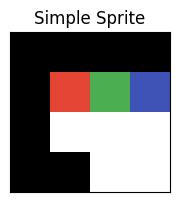

In [5]:
sprite = [
    [0, 0, 0, 0],
    [0, 2, 3, 4],
    [0, 1, 1, 1],
    [0, 0, 1, 1]
]

fig, ax = draw_pixel_art(sprite, pixel_size=4)
plt.title("Simple Sprite", fontsize=12)
plt.show()

## Example 2: Space Invader

A classic arcade character:

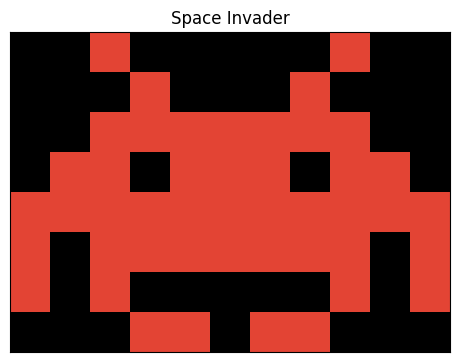

In [6]:
invader = [
    [0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0],
    [0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0],
    [0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0],
    [0, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0],
    [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
    [2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2],
    [2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2],
    [0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0],
]

fig, ax = draw_pixel_art(invader, pixel_size=4)
plt.title("Space Invader", fontsize=12)
plt.show()

## Example 3: Custom Color Palette

Create your own color scheme:

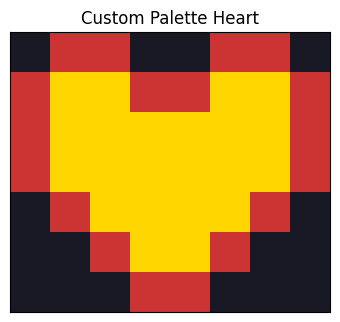

In [7]:
# Define custom colors (RGB values from 0 to 1)
custom_palette = {
    0: (0.1, 0.1, 0.15),  # Dark blue background
    1: (1.0, 0.84, 0.0),  # Gold
    2: (0.8, 0.2, 0.2),   # Dark red
    3: (0.2, 0.8, 0.2),   # Bright green
}

heart = [
    [0, 2, 2, 0, 0, 2, 2, 0],
    [2, 1, 1, 2, 2, 1, 1, 2],
    [2, 1, 1, 1, 1, 1, 1, 2],
    [2, 1, 1, 1, 1, 1, 1, 2],
    [0, 2, 1, 1, 1, 1, 2, 0],
    [0, 0, 2, 1, 1, 2, 0, 0],
    [0, 0, 0, 2, 2, 0, 0, 0],
]

fig, ax = draw_pixel_art(heart, color_palette=custom_palette, pixel_size=4)
plt.title("Custom Palette Heart", fontsize=12)
plt.show()

## Example 4: Mario-Style Mushroom

A power-up sprite:

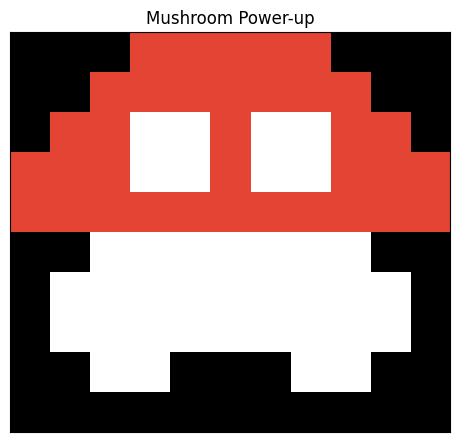

In [8]:
mushroom = [
    [0, 0, 0, 2, 2, 2, 2, 2, 0, 0, 0],
    [0, 0, 2, 2, 2, 2, 2, 2, 2, 0, 0],
    [0, 2, 2, 1, 1, 2, 1, 1, 2, 2, 0],
    [2, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2],
    [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

fig, ax = draw_pixel_art(mushroom, pixel_size=4)
plt.title("Mushroom Power-up", fontsize=12)
plt.show()

## Create Your Own!

Use this cell to design your own pixel art:

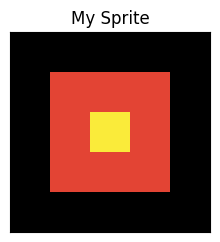

In [9]:
# Create your own design here!
my_sprite = [
    [0, 0, 0, 0, 0],
    [0, 2, 2, 2, 0],
    [0, 2, 5, 2, 0],
    [0, 2, 2, 2, 0],
    [0, 0, 0, 0, 0],
]

fig, ax = draw_pixel_art(my_sprite, pixel_size=4)
plt.title("My Sprite", fontsize=12)
plt.show()

## Saving Your Pixel Art

Save your creation to a file:

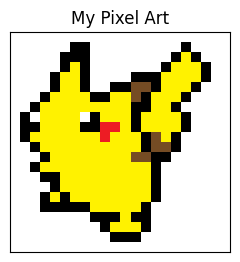

Saved to: my_pixel_art.png


In [13]:
# Create your sprite
my_design = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 0],
    [0, 0, 0, 0, 1, 2, 2, 1, 0, 0, 0, 0, 1, 1, 1, 2, 2, 2, 2, 1, 0, 0],
    [0, 0, 0, 0, 1, 2, 2, 1, 0, 0, 1, 1, 4, 4, 1, 2, 2, 2, 1, 0, 0, 0],
    [0, 0, 0, 1, 2, 2, 2, 2, 1, 1, 2, 2, 4, 1, 2, 2, 2, 1, 0, 0, 0, 0],
    [0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 1, 0, 0, 0, 0, 0],
    [0, 1, 0, 2, 2, 2, 2, 0, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 0, 0, 0, 0],
    [0, 1, 1, 2, 2, 2, 2, 1, 1, 3, 3, 2, 1, 2, 2, 2, 2, 1, 0, 0, 0, 0],
    [0, 1, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 1, 4, 2, 1, 0, 0, 0, 0, 0],
    [0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 4, 4, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 1, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
]

color_palette = {
    0: (255/255, 255/255, 255/255), # White (background)
    1: (0/255, 0/255, 0/255),       # Black
    2: (255/255, 242/255, 0/255),   # Yellow
    3: (237/255, 28/255, 36/255),   # Red
    4: (117/255, 76/255, 36/255),   # Brown
}

# Draw and save
fig, ax = draw_pixel_art(my_design, color_palette, pixel_size=1)
plt.title("My Pixel Art", fontsize=12)
plt.savefig('my_pixel_art.png', dpi=150, bbox_inches='tight', pad_inches=0.1)
plt.show()

print("Saved to: my_pixel_art.png")

## Tips for Creating Pixel Art

1. **Start small**: 8×8 or 16×16 matrices work great for classic sprites
2. **Use 0 for background**: Keep empty areas as 0 (black/transparent)
3. **Limit colors**: Real 8-bit games used 3-4 colors per sprite
4. **Symmetry**: Many classic sprites are symmetrical
5. **Outline**: Use a dark color (like 2) for outlines

## RGB Color Helper

Convert hex colors to RGB (0-1 range):

In [11]:
def hex_to_rgb(hex_color):
    """
    Convert hex color to RGB tuple (0-1 range)
    Example: hex_to_rgb('#FF5733') -> (1.0, 0.341, 0.2)
    """
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))

# Example usage
print("Red (#FF0000):", hex_to_rgb('#FF0000'))
print("Green (#00FF00):", hex_to_rgb('#00FF00'))
print("Blue (#0000FF):", hex_to_rgb('#0000FF'))
print("Custom (#FF5733):", hex_to_rgb('#FF5733'))

Red (#FF0000): (1.0, 0.0, 0.0)
Green (#00FF00): (0.0, 1.0, 0.0)
Blue (#0000FF): (0.0, 0.0, 1.0)
Custom (#FF5733): (1.0, 0.3411764705882353, 0.2)


## Advanced: Display Multiple Sprites

Show several sprites in a grid:

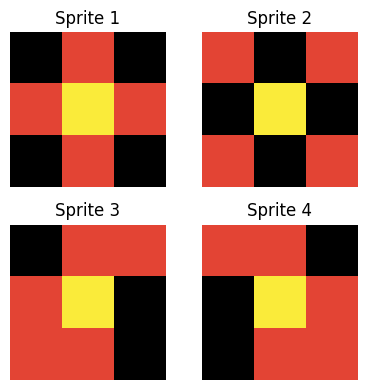

In [12]:
# Create multiple sprites
sprite1 = [[0, 2, 0], [2, 5, 2], [0, 2, 0]]
sprite2 = [[2, 0, 2], [0, 5, 0], [2, 0, 2]]
sprite3 = [[0, 2, 2], [2, 5, 0], [2, 2, 0]]
sprite4 = [[2, 2, 0], [0, 5, 2], [0, 2, 2]]

sprites = [sprite1, sprite2, sprite3, sprite4]
titles = ['Sprite 1', 'Sprite 2', 'Sprite 3', 'Sprite 4']

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(4, 4))
axes = axes.flatten()

for i, (sprite, title) in enumerate(zip(sprites, titles)):
    matrix = np.array(sprite)
    axes[i].imshow(matrix, cmap=ListedColormap([
        (0, 0, 0), (1, 1, 1), (0.894, 0.267, 0.204),
        (0.298, 0.686, 0.314), (0.247, 0.318, 0.710),
        (0.984, 0.922, 0.231)
    ]), interpolation='nearest')
    axes[i].set_title(title)
    axes[i].axis('off')

plt.tight_layout()
plt.show()